# Random forest for regression

[Master Tree Ensemble Models course](https://www.trainindata.com/p/master-tree-ensemble-models)

In this notebook, we train a random forest to predict the rent price of an apartment. We start with the default parameters, then we look at how the number of trees and the depth of the trees affect the performance, and finally we tune the hyperparameters with a random search.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split

### Load data

We use the apartment rent data that we prepared in the notebook of the folder prepare-data.

In [2]:
df = pd.read_csv("../prepare-data/apartment_rent.csv", index_col="time")
df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,...,amenity_Patio/Deck,amenity_Playground,amenity_Pool,amenity_Refrigerator,amenity_Storage,amenity_TV,amenity_Tennis,amenity_View,amenity_Washer Dryer,amenity_Wood Floors
time,,,,,,,,,,,,,,,,,,,,,
2018-12-07 09:20:18,housing/rent/apartment,1.0,1.0,No,Thumbnail,Not specified,1191.0,800.0,Atlanta,GA,...,0,0,0,0,0,1,0,0,0,0
2018-12-07 09:20:32,housing/rent/apartment,2.0,4.0,No,Yes,Not specified,1450.0,1880.0,Orange Park,FL,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:44,housing/rent/apartment,2.0,3.0,No,Yes,Not specified,1395.0,1661.0,Orange Park,FL,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:55,housing/rent/apartment,2.0,3.0,No,Yes,Not specified,1255.0,1400.0,Orange Park,FL,...,0,0,0,0,0,0,1,0,0,0
2018-12-07 09:20:58,housing/rent/apartment,2.0,2.0,No,Yes,Not specified,1693.0,1346.0,Atlanta,GA,...,0,0,0,0,0,1,0,0,0,0


In [3]:
# the trees from Scikit-learn take numbers, so we replace the categories by integers
categorical_vars = df.select_dtypes("str").columns
df[categorical_vars] = df[categorical_vars].apply(lambda var: var.astype("category").cat.codes)

df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,...,amenity_Patio/Deck,amenity_Playground,amenity_Pool,amenity_Refrigerator,amenity_Storage,amenity_TV,amenity_Tennis,amenity_View,amenity_Washer Dryer,amenity_Wood Floors
time,,,,,,,,,,,,,,,,,,,,,
2018-12-07 09:20:18,1,1.0,1.0,0,1,0,1191.0,800.0,101,10,...,0,0,0,0,0,1,0,0,0,0
2018-12-07 09:20:32,1,2.0,4.0,0,2,0,1450.0,1880.0,1955,9,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:44,1,2.0,3.0,0,2,0,1395.0,1661.0,1955,9,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:55,1,2.0,3.0,0,2,0,1255.0,1400.0,1955,9,...,0,0,0,0,0,0,1,0,0,0
2018-12-07 09:20:58,1,2.0,2.0,0,2,0,1693.0,1346.0,101,10,...,0,0,0,0,0,1,0,0,0,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns="price"),
    df["price"],
    test_size=0.3,
    random_state=0,
)

X_train.shape, X_test.shape

((69872, 39), (29946, 39))

### Train the model with the default parameters

We show the hyperparameters with their default values, so that we can see the effect of changing them later on.

In [5]:
rf = RandomForestRegressor(
    # the ensemble
    n_estimators=100,
    bootstrap=True,
    max_samples=None,
    max_features="sqrt", # important to set this parameter because it defaults to all features otherwise
    oob_score=False,

    # how far each tree grows
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,

    # pruning and reproducibility
    ccp_alpha=0.0,
    random_state=0,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,

In [6]:
def evaluate(model, X_train, y_train, X_test, y_test):
    for name, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        rmse = root_mean_squared_error(y, model.predict(X))
        r2 = r2_score(y, model.predict(X))
        print(f"{name} rmse: {rmse:.2f}, r2: {r2:.4f}")


evaluate(rf, X_train, y_train, X_test, y_test)

train rmse: 176.98, r2: 0.9628
test rmse: 395.07, r2: 0.7936


The forest predicts the rent much better than the single decision tree of the previous section, and again we obtained this without tuning anything.

Notice that the forest still fits the train set very closely, and yet the error in the test set is lower than the error of the tuned tree, which shows that the averaging of many trees is what keeps the variance under control.

### The number of trees

We train forests with a growing number of trees and we evaluate them in the test set.

In [7]:
n_estimators = [5, 10, 25, 50, 100, 200, 400, 1000]

rmse_values = []
for n in n_estimators:
    model = RandomForestRegressor(
        n_estimators=n, 
        max_features="sqrt",
        random_state=0, n_jobs=-1)
    
    model.fit(X_train, y_train)
    rmse_values.append(root_mean_squared_error(y_test, model.predict(X_test)))

pd.Series(rmse_values, index=n_estimators).round(1)

5       455.3
10      415.9
25      398.7
50      397.8
100     395.1
200     391.2
400     388.7
1000    388.0
dtype: float64

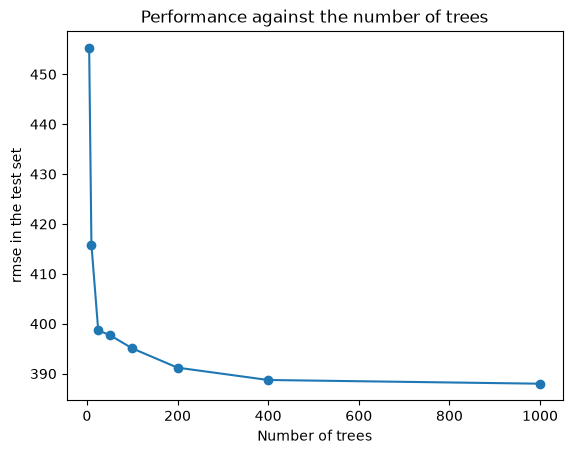

In [8]:
plt.plot(n_estimators, rmse_values, marker="o")
plt.xlabel("Number of trees")
plt.ylabel("rmse in the test set")
plt.title("Performance against the number of trees")
plt.show()

The error drops quickly at the beginning and then it flattens, and after that point more trees cost us time without giving us anything back. Adding trees never hurts the performance, so in practice we can set a large number of trees and be safe, and the only thing we pay is the training time.

### The depth of the trees

The theory tells us that random forests work better with deep trees, because the averaging of many different trees is what controls the variance. We compare forests with shallow trees and forests with trees that grow without a limit.

In [9]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20, 24, 30, 40]

results = {}
for depth in depths:
    model = RandomForestRegressor(
        max_depth=depth,     
        max_features="sqrt",
        random_state=0, n_jobs=-1)
    
    model.fit(X_train, y_train)
    results[depth] = {
        "train": root_mean_squared_error(y_train, model.predict(X_train)),
        "test": root_mean_squared_error(y_test, model.predict(X_test)),
    }

results = pd.DataFrame(results).T
results.round(1)

,train,test
2,822.2,789.7
3,773.9,748.6
4,735.3,713.5
5,694.8,677.4
6,657.6,645.9
8,575.6,586.0
10,513.0,544.1
12,442.1,503.4
14,387.2,467.2
16,335.5,442.9


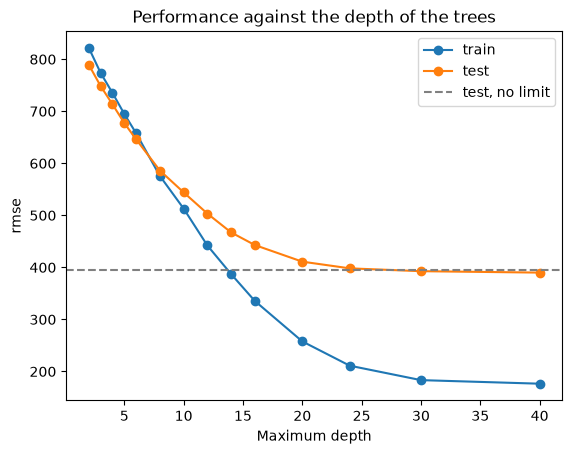

In [10]:
# the dashed line is the forest of the beginning, the one that grows without a limit
plt.plot(results.index, results["train"], marker="o", label="train")
plt.plot(results.index, results["test"], marker="o", label="test")
plt.axhline(root_mean_squared_error(y_test, rf.predict(X_test)), color="grey", linestyle="dashed", label="test, no limit")
plt.xlabel("Maximum depth")
plt.ylabel("rmse")
plt.title("Performance against the depth of the trees")
plt.legend()
plt.show()

### Search for better hyperparameters

We keep the number of trees fixed at a value that is large enough, and we sample the hyperparameters that control the growth of the trees and the randomness of the forest.

In [11]:
param_distributions = {
    "max_depth": randint(5, 30),
    "min_samples_leaf": randint(1, 50),
    "max_features": uniform(0.1, 0.6),
}

search = RandomizedSearchCV(
    RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        random_state=0, 
        n_jobs=-1),
    param_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=0,
)

search.fit(X_train, y_train)

search.best_params_

{'max_depth': 17,
 'max_features': np.float64(0.455706770935011),
 'min_samples_leaf': 1}

In [12]:
# the standard deviation tells us how much the metric changes across the folds
results = pd.DataFrame(search.cv_results_)
results = results.sort_values("rank_test_score")

results[["mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,mean_test_score,std_test_score,rank_test_score
0,-454.285378,83.704398,1
6,-508.525428,96.143233,2
8,-514.661867,96.532222,3
3,-537.232650,98.656476,4
14,-549.400045,98.708408,5
10,-549.681702,98.687452,6
5,-556.363255,96.594571,7
9,-559.305051,98.948738,8
2,-567.630996,98.248755,9
11,-568.466496,98.739031,10


In [13]:
best = results.iloc[0]

print(f"best cross validation rmse: {-best['mean_test_score']:.2f} +/- {best['std_test_score']:.2f}")

best cross validation rmse: 454.29 +/- 83.70


### Evaluate the new model

We compare the performance of the tuned forest with the performance of the forest that we trained with the default hyperparameters.

In [14]:
evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)

train rmse: 234.86, r2: 0.9345
test rmse: 393.78, r2: 0.7949


### How certain is the forest

Each tree of the forest makes its own prediction, and the prediction of the forest is their average. 

When we use predict, we only see the average, but we can dig a bit deeper and obtain the dispersion as well, so we know how confident the forest is in its prediction.

In the following code, we obtain predictions from each tree, and then average them manually and while we are at it, we take the standard deviation as well.

When the trees agree, we can be confident about the prediction, and when they disagree, the forest is telling us that it is unsure, so the spread of the predictions of the trees gives us an estimate of the uncertainty.

In [15]:
# the trees of the forest were trained with arrays, so we pass the values
import numpy as np
tree_predictions = np.array([tree.predict(X_test.to_numpy()) for tree in rf.estimators_])

predictions = pd.DataFrame({
    "prediction": tree_predictions.mean(axis=0),
    "uncertainty": tree_predictions.std(axis=0),
    "real": y_test.to_numpy(),
})
predictions["error"] = (predictions["prediction"] - predictions["real"]).abs()

predictions.head().round(2)

,prediction,uncertainty,real,error
0,1478.71,342.49,1599.0,120.29
1,1005.62,183.62,950.0,55.62
2,756.44,84.33,730.0,26.44
3,1840.13,216.93,2013.0,172.87
4,1164.81,263.28,900.0,264.81


In [16]:
# we sort the apartments in five groups, from the most certain to the least certain
groups = pd.qcut(predictions["uncertainty"], 5, labels=False).rename("group")

predictions.groupby(groups)[["uncertainty", "error"]].mean().round(1)

,uncertainty,error
group,,
0,63.6,43.7
1,169.3,84.7
2,249.4,132.1
3,351.5,187.4
4,815.3,421.2


The error grows together with the disagreement between the trees, so we can use the spread as a warning that tells us which predictions we should not trust, and this comes for free with the model that we already trained.

### The output is still a series of steps

Each tree returns the average price of the apartments of a leaf, so each tree is a series of steps, and the forest returns the average of those steps. The output of the forest is therefore still a series of steps, and the only thing that changes is that there are many more of them, because every tree contributes its own cut points. With enough trees the steps become so small and so numerous that the output looks continuous, and in practice we stop noticing.

In [17]:
small_forest = RandomForestRegressor(n_estimators=3, max_depth=4, random_state=0)
small_forest.fit(X_train, y_train)

print(f"apartments in the test set: {len(y_test)}")
print(f"different predictions of three shallow trees: {len(pd.unique(small_forest.predict(X_test)))}")
print(f"different predictions of the forest: {len(pd.unique(rf.predict(X_test)))}")

apartments in the test set: 29946
different predictions of three shallow trees: 37
different predictions of the forest: 27048


### The forest does not extrapolate

The prediction of a tree is the average price of the apartments of a leaf, and the prediction of the forest is the average of those averages, so a forest can only ever return values that live inside the range of the prices that it saw during training.

Within that range the forest interpolates very well, and beyond it the prediction simply stops growing, because the apartments that are larger than anything in the train set all fall in the same final leaves and receive the same answer. A linear model would keep extending the line, while the forest draws a flat line for ever.

![Random forests do not extrapolate](extrapolation.png)

This matters whenever the data changes with time, for example when the rents of a city grow year after year, because a forest trained on the rents of today will never predict a price above the ones that it has already seen.